In [ ]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import PredefinedSplit, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from utils.model_saver import *
from utils.model_classes import KNNModel

PROJECT_ROOT = Path().resolve().parent.parent.parent.parent
print(f"Project root: {PROJECT_ROOT}")
PATH_DATA = PROJECT_ROOT / 'data' / 'exploded_splits'
print(f"Data: {PATH_DATA}")

GRAPH_FEATURES_PATH = PROJECT_ROOT / 'data' / 'graph_features'
TRAIN_PATH = GRAPH_FEATURES_PATH / 'final_train.parquet'
VAL_PATH = GRAPH_FEATURES_PATH / 'final_val.parquet'
TEST_PATH = GRAPH_FEATURES_PATH / 'final_test.parquet'

RANDOM_STATE = 42

Project root: C:\Users\ivan.bernacchia\OneDrive - TINEXT SA\Documents\_Alessia\M-P6203E-DataProjects-Hackaton3_P1
Data: C:\Users\ivan.bernacchia\OneDrive - TINEXT SA\Documents\_Alessia\M-P6203E-DataProjects-Hackaton3_P1\data\exploded_splits


# KNN based Model - on graph features
By leveraging graph features (network info), we treat the problem as a supervised learning task.

To ensure code quality and reusability, we implement a custom class hierarchy:

- `BaseModel`: An abstract class that defines the blueprint for all models. It enforces the implementation of `preprocess()` method and provides standardized `train_pipeline` and `test_pipeline` methods.

- `KNNModel`: The concrete implementation of the baseline. It encapsulates the feature engineering logic (dropping non-feature columns) and stateful preprocessing (storing a `StandardScaler` to ensure the test set is scaled using training statistics).


## 1. Import dataframe with graph features

In [2]:
# splitting
df_train = pd.read_parquet(TRAIN_PATH)
df_val = pd.read_parquet(VAL_PATH)
df_test = pd.read_parquet(TEST_PATH)

print("\nSplit sizes:", {"train": len(df_train), "test": len(df_test), "val": len(df_val)})


Split sizes: {'train': 2162520, 'test': 396382, 'val': 391242}


## 2. Baseline Model

[KNN] Preprocessing data...
Label distribution:
is_reference_valid
0    0.5009
1    0.4991
Name: proportion, dtype: float64
[KNN] Starting training...
              precision    recall  f1-score   support

           0     0.8883    0.9225    0.9051      5009
           1     0.9191    0.8836    0.9010      4991

    accuracy                         0.9031     10000
   macro avg     0.9037    0.9031    0.9031     10000
weighted avg     0.9037    0.9031    0.9031     10000



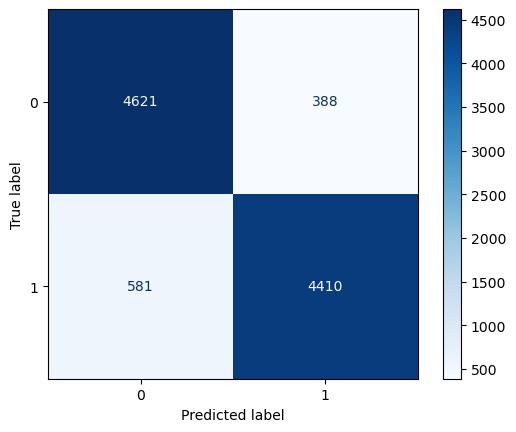

In [3]:
KNN_baseline = KNNModel('KNN_baseline', n_neighbors=5, weights='uniform', metric='minkowski')
KNN_baseline = KNNModel()

KNN_baseline.train_pipeline(df_train.sample(10000))

[KNN] Preprocessing data...
Label distribution:
is_reference_valid
0    0.5032
1    0.4968
Name: proportion, dtype: float64
              precision    recall  f1-score   support

           0     0.6538    0.9442    0.7726      5032
           1     0.8972    0.4936    0.6368      4968

    accuracy                         0.7203     10000
   macro avg     0.7755    0.7189    0.7047     10000
weighted avg     0.7747    0.7203    0.7051     10000



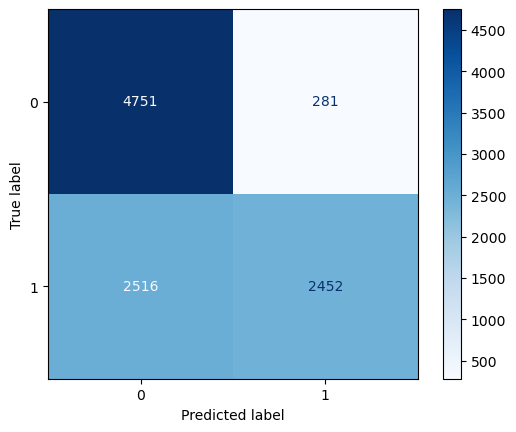

In [4]:
KNN_baseline.test_pipeline(df_test.sample(10000))

## 3. Hypertuning
Given the high dimensionality of embeddings and the large number of records, KNN can be computationally expensive. To optimize performance, we perform `GridSearchCV` on a representative subset of the data.

We utilize a `PredefinedSplit` strategy. Instead of standard K-fold cross-validation, we manually specify which samples belong to the training fold and which belong to the validation fold. This ensures that the model is tuned on the exact data distribution intended for validation without leakage from the training set.

In [5]:
# Drastically reduce the dataset for tuning to avoid Out-Of-Memory (OOM) crashes
# KNN with 3M rows and 128-256 features is extremely RAM-intensive
max_tuning_samples = 50000 
param_grid = {
    'n_neighbors': [5, 9, 12, 15], # Reduced number of parameters
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Downsampling for speed
def downsample_indices(indices, n_samples):
    if len(indices) > n_samples:
        return np.random.choice(indices, n_samples, replace=False)
    return indices

In [6]:
# tuning
tuner_model = KNNModel() # model to preprocess data
X_train_scaled, y_train = tuner_model.preprocess(df_train, is_training=True)
X_val_scaled, y_val = tuner_model.preprocess(df_val, is_training=False)

# sample for tuning
train_tuning_idx = downsample_indices(np.arange(len(X_train_scaled)), int(max_tuning_samples * 0.8))
val_tuning_idx = downsample_indices(np.arange(len(X_val_scaled)), int(max_tuning_samples * 0.2))

X_subset = np.vstack((X_train_scaled[train_tuning_idx], X_val_scaled[val_tuning_idx]))
y_subset = np.concatenate((y_train.iloc[train_tuning_idx], y_val.iloc[val_tuning_idx]))

# Create split indices: -1 for train, 0 for validation
split_index = np.concatenate([-1 * np.ones(len(train_tuning_idx)), 0 * np.ones(len(val_tuning_idx))])
ps = PredefinedSplit(test_fold=split_index)

# GridSearchCV
print(f"\nStarting tuning on {len(X_subset)} samples...")
grid_search = GridSearchCV(
    KNeighborsClassifier(n_jobs=-1),
    param_grid=param_grid,
    cv=ps,
    scoring='f1_weighted',
    n_jobs=-1
)
grid_search.fit(X_subset, y_subset)

[KNN] Preprocessing data...
Label distribution:
is_reference_valid
1    0.5
0    0.5
Name: proportion, dtype: float64
[KNN] Preprocessing data...
Label distribution:
is_reference_valid
1    0.5
0    0.5
Name: proportion, dtype: float64
Starting tuning on 50000 samples...


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsCla...ier(n_jobs=-1)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'manhattan'], 'n_neighbors': [5, 9, ...], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.","PredefinedSpl...ape=(50000,)))"
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each

In [12]:
best_params = grid_search.best_params_
print("\nBest parameters found:")
print(best_params)

# Final training on the full dataset with the best parameters
model = grid_search.best_estimator_
model.fit(X_train_scaled, y_train)

print(f"\nOptimal model ready: {model}")


Best parameters found:
{'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}

Optimal model ready: KNeighborsClassifier(metric='manhattan', n_jobs=-1)


## 4. Final model with best params
Once the optimal hyperparameters (number of neighbors, weight function, and distance metric) are found, the model is retrained on the full training set.

Performance is assessed using:
- Weighted F1-Score: To account for any slight imbalances in class distribution.
- Confusion Matrix: To visualize Type I and Type II errors.
- Classification Report: Providing precision, recall, and accuracy at a granular level.

Train model with best params...
[KNN_textual] Preprocessing data...
Label distribution:
is_reference_valid
1    0.5001
0    0.4999
Name: proportion, dtype: float64
[KNN_textual] Starting training...
              precision    recall  f1-score   support

           0     0.9105    0.9322    0.9212      4999
           1     0.9306    0.9084    0.9194      5001

    accuracy                         0.9203     10000
   macro avg     0.9205    0.9203    0.9203     10000
weighted avg     0.9205    0.9203    0.9203     10000



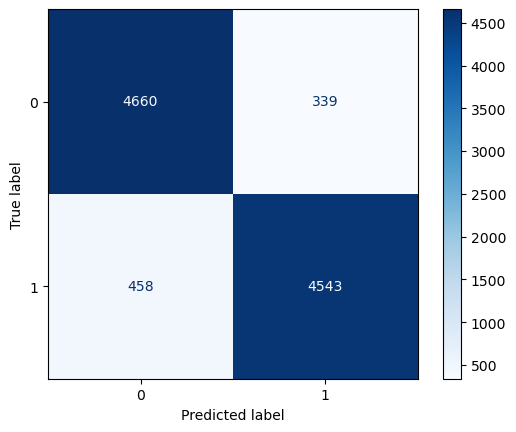

In [ ]:
# final training creating model with best params
final_knn = KNNModel("KNN_textual", **best_params)

print(f'Train model with best params...')
final_knn.train_pipeline(df_train.sample(10000))

[KNN_textual] Preprocessing data...
Label distribution:
is_reference_valid
0    0.532
1    0.468
Name: proportion, dtype: float64
              precision    recall  f1-score   support

           0     0.8406    0.8722    0.8561       532
           1     0.8482    0.8120    0.8297       468

    accuracy                         0.8440      1000
   macro avg     0.8444    0.8421    0.8429      1000
weighted avg     0.8442    0.8440    0.8437      1000



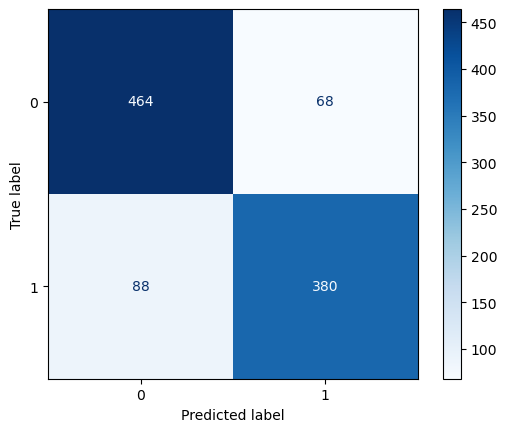

In [ ]:
final_knn.test_pipeline(df_test.sample(1000))

## 5. Save the Model pretrained
Finally, the trained model and its associated metadata (parameters, data source name, and performance summary) are saved using a custom `save_model_artifact` utility, allowing for easy deployment or further testing.

In [15]:
df_name = "knn_textual_embeddings_128"
model_family = "knn"
model_name = "knn_classifier"
split_name = "predefined_train_validation_test"
summary = {
        "scoring": "f1_weighted",
        "max_tuning_samples": int(max_tuning_samples),
        "train_subset_size": int(len(train_tuning_idx)),
        "val_subset_size": int(len(val_tuning_idx)),
    },

final_knn.save_model(params = best_params, df_name=df_name, model_family=model_family, split_name=split_name, summary=summary, force=False)

ValueError: dictionary update sequence element #0 has length 4; 2 is required